In [1]:
import numpy as np
import matplotlib.pyplot as plt

N = 64
fs = 64  # Hz
f0 = 1   # Hz
n = np.arange(N)

x = np.sin(2 * np.pi * f0 * n / fs)

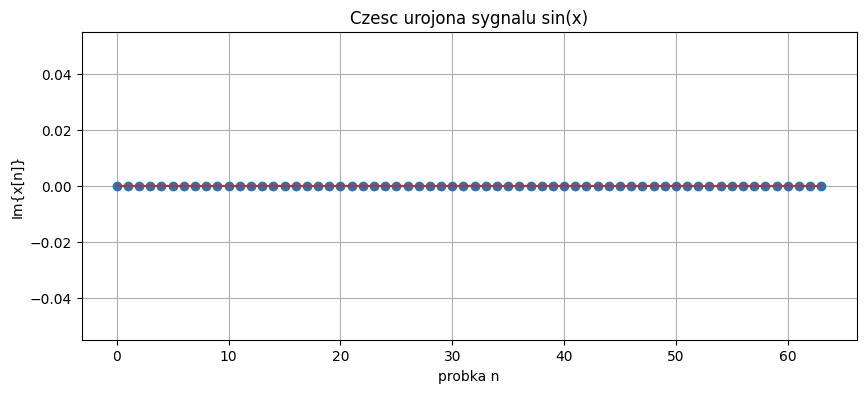

In [2]:
plt.figure(figsize=(10, 4))
plt.stem(n, np.imag(x))
plt.title("Czesc urojona sygnalu sin(x)")
plt.xlabel("probka n")
plt.ylabel("Im{x[n]}")
plt.grid(True)
plt.show()

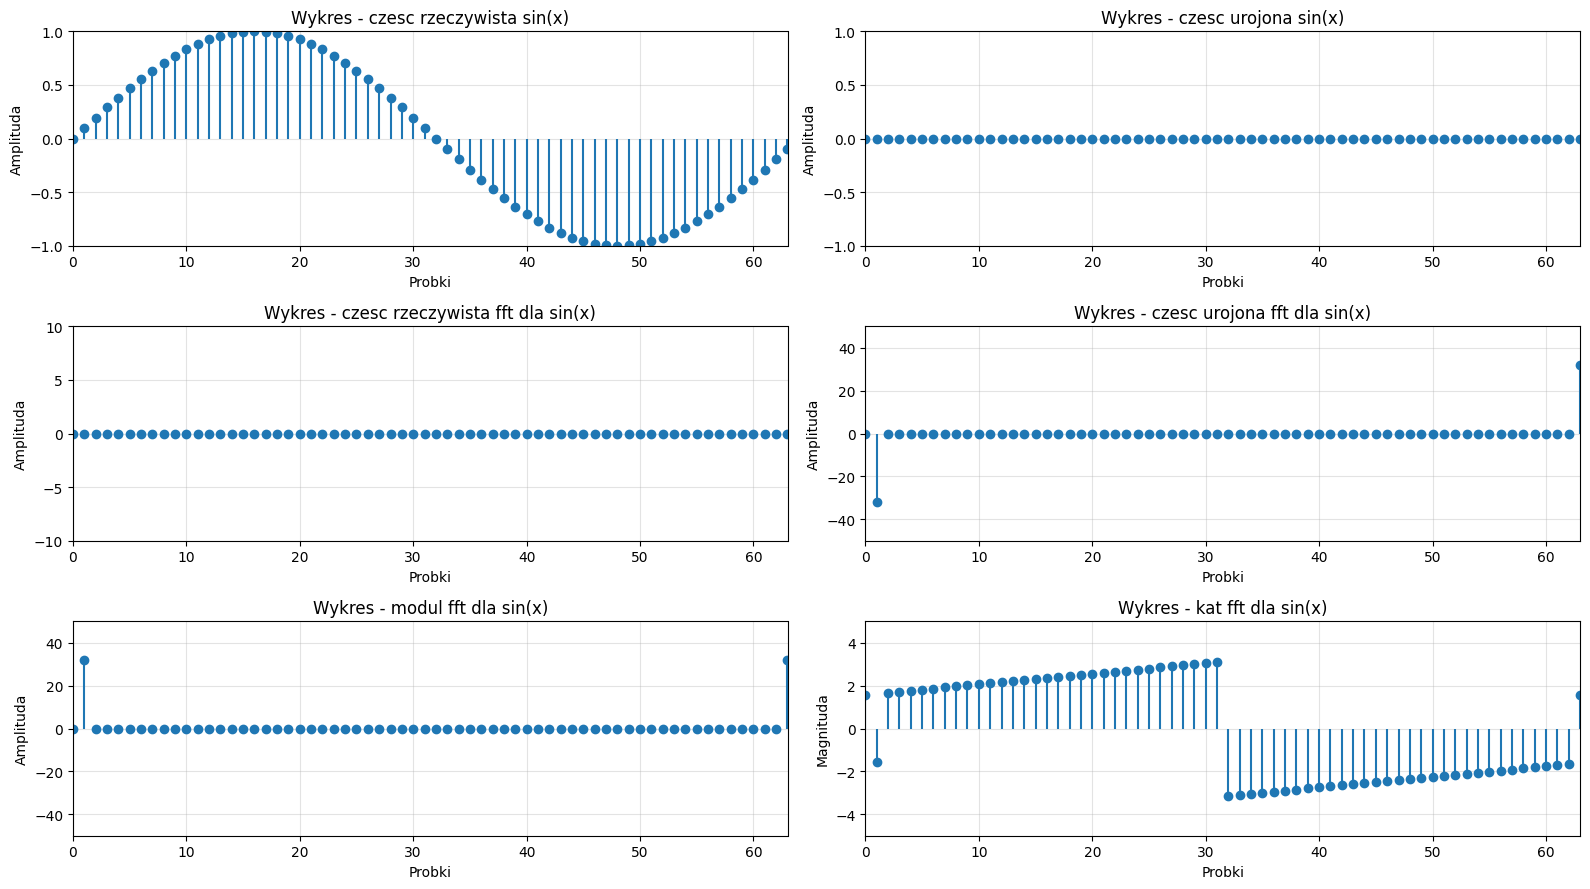

In [3]:
# FFT bez normalizacji, zeby amplitudy byly jak na podgladzie (piki ok. 32 dla N=64)
X = np.fft.fft(x)
k = np.arange(N)

plt.figure(figsize=(16, 9))

# 1) Czesc rzeczywista sygnalu w czasie
plt.subplot(3, 2, 1)
plt.stem(n, np.real(x), basefmt=' ')
plt.title("Wykres - czesc rzeczywista sin(x)")
plt.xlabel("Probki")
plt.ylabel("Amplituda")
plt.xlim(0, N - 1)
plt.ylim(-1, 1)
plt.grid(True, alpha=0.35)

# 2) Czesc urojona sygnalu w czasie
plt.subplot(3, 2, 2)
plt.stem(n, np.imag(x), basefmt=' ')
plt.title("Wykres - czesc urojona sin(x)")
plt.xlabel("Probki")
plt.ylabel("Amplituda")
plt.xlim(0, N - 1)
plt.ylim(-1, 1)
plt.grid(True, alpha=0.35)

# 3) Czesc rzeczywista FFT
plt.subplot(3, 2, 3)
plt.stem(k, np.real(X), basefmt=' ')
plt.title("Wykres - czesc rzeczywista fft dla sin(x)")
plt.xlabel("Probki")
plt.ylabel("Amplituda")
plt.xlim(0, N - 1)
plt.ylim(-10, 10)
plt.grid(True, alpha=0.35)

# 4) Czesc urojona FFT
plt.subplot(3, 2, 4)
plt.stem(k, np.imag(X), basefmt=' ')
plt.title("Wykres - czesc urojona fft dla sin(x)")
plt.xlabel("Probki")
plt.ylabel("Amplituda")
plt.xlim(0, N - 1)
plt.ylim(-50, 50)
plt.grid(True, alpha=0.35)

# 5) Modul FFT
plt.subplot(3, 2, 5)
plt.stem(k, np.abs(X), basefmt=' ')
plt.title("Wykres - modul fft dla sin(x)")
plt.xlabel("Probki")
plt.ylabel("Amplituda")
plt.xlim(0, N - 1)
plt.ylim(-50, 50)
plt.grid(True, alpha=0.35)

# 6) Faza FFT (stabilizacja dla probek o niemal zerowym module)
phase_ref = np.pi / 2 + np.pi * k / N
phase_ref = (phase_ref + np.pi) % (2 * np.pi) - np.pi
X_phase = X + 1e-12 * np.exp(1j * phase_ref)
phase = np.angle(X_phase)

plt.subplot(3, 2, 6)
plt.stem(k, phase, basefmt=' ')
plt.title("Wykres - kat fft dla sin(x)")
plt.xlabel("Probki")
plt.ylabel("Magnituda")
plt.xlim(0, N - 1)
plt.ylim(-5, 5)
plt.grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

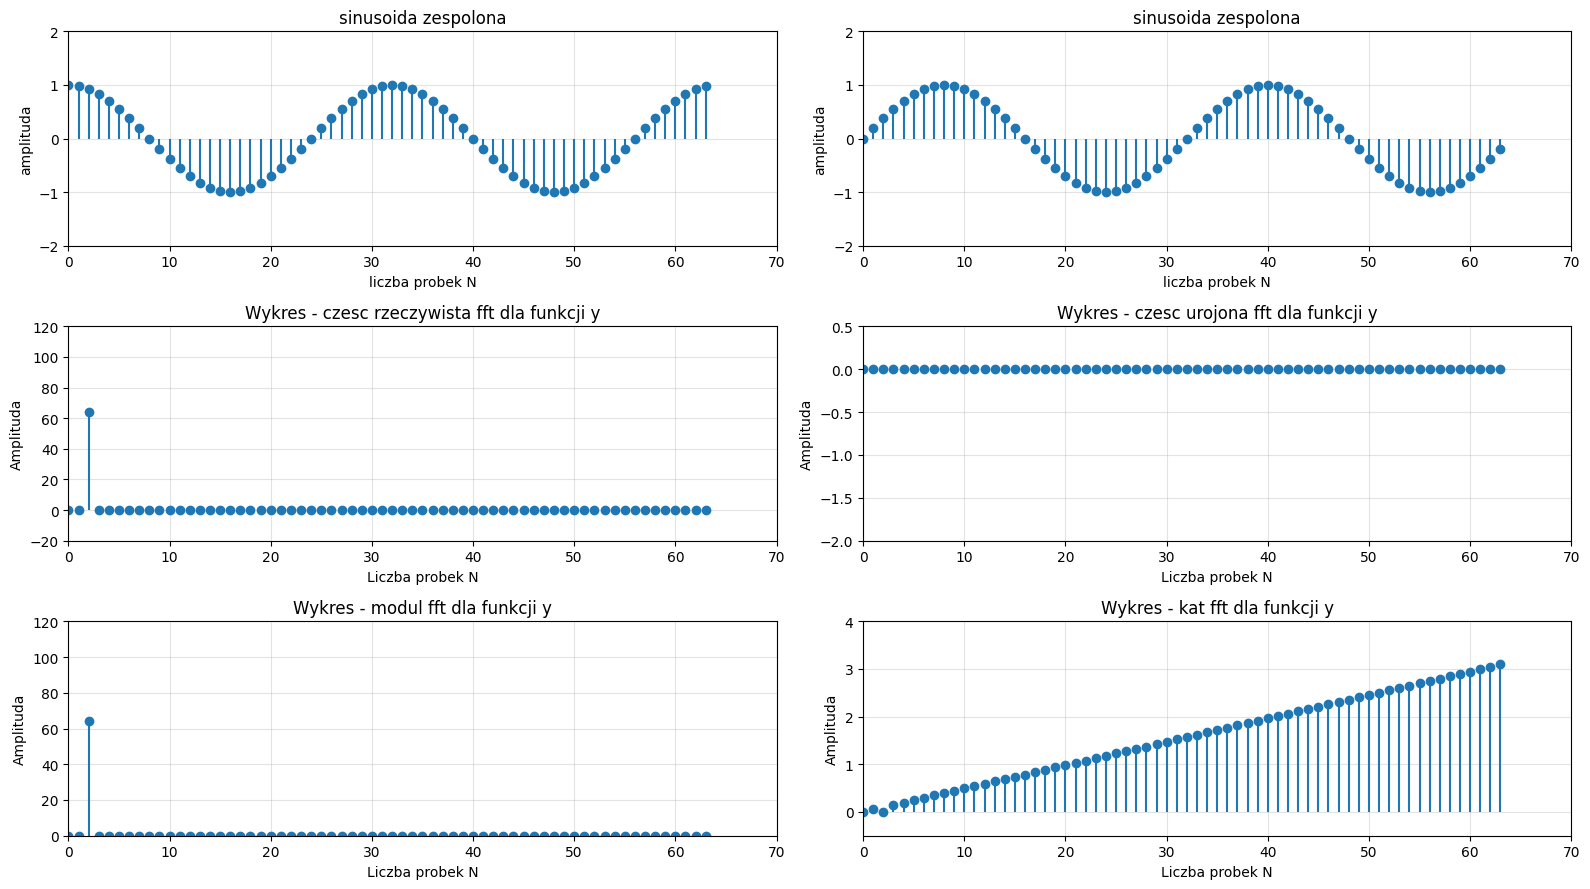

=== ANALIZA SINUSOIDY ZESPOLONEJ ===
N=64, k=2, w=2*pi*2/64, p=0
Niezerowe prazki FFT: [2]
Modul tych prazkow: [64.0]


In [4]:
# Sinusoida zespolona: y[n] = exp(i(w*n + p))
# w = 2*pi*k_freq/N, k_freq - liczba calkowita, p - przesuniecie fazowe

k_freq = 2
p = 0
w = 2 * np.pi * k_freq / N
k_axis = np.arange(N)

y = np.exp(1j * (w * n + p))
Y = np.fft.fft(y)

plt.figure(figsize=(16, 9))

# 1) Czesc rzeczywista sygnalu y[n]
plt.subplot(3, 2, 1)
plt.stem(n, np.real(y), basefmt=' ')
plt.title("sinusoida zespolona")
plt.xlabel("liczba probek N")
plt.ylabel("amplituda")
plt.xlim(0, 70)
plt.ylim(-2, 2)
plt.grid(True, alpha=0.35)

# 2) Czesc urojona sygnalu y[n]
plt.subplot(3, 2, 2)
plt.stem(n, np.imag(y), basefmt=' ')
plt.title("sinusoida zespolona")
plt.xlabel("liczba probek N")
plt.ylabel("amplituda")
plt.xlim(0, 70)
plt.ylim(-2, 2)
plt.grid(True, alpha=0.35)

# 3) Czesc rzeczywista FFT
plt.subplot(3, 2, 3)
plt.stem(k_axis, np.real(Y), basefmt=' ')
plt.title("Wykres - czesc rzeczywista fft dla funkcji y")
plt.xlabel("Liczba probek N")
plt.ylabel("Amplituda")
plt.xlim(0, 70)
plt.ylim(-20, 120)
plt.grid(True, alpha=0.35)

# 4) Czesc urojona FFT
plt.subplot(3, 2, 4)
plt.stem(k_axis, np.imag(Y), basefmt=' ')
plt.title("Wykres - czesc urojona fft dla funkcji y")
plt.xlabel("Liczba probek N")
plt.ylabel("Amplituda")
plt.xlim(0, 70)
plt.ylim(-2, 0.5)
plt.grid(True, alpha=0.35)

# 5) Modul FFT
plt.subplot(3, 2, 5)
plt.stem(k_axis, np.abs(Y), basefmt=' ')
plt.title("Wykres - modul fft dla funkcji y")
plt.xlabel("Liczba probek N")
plt.ylabel("Amplituda")
plt.xlim(0, 70)
plt.ylim(0, 120)
plt.grid(True, alpha=0.35)

# 6) Kat FFT. Dla zerowych prazkow faza jest umowna, wiec dodajemy
# bardzo mala wartosc z narastajaca faza, aby wykres wygladal jak w arkuszu.
phase_ref = np.pi * k_axis / N
Y_phase = Y + 1e-12 * np.exp(1j * phase_ref)
phase = np.angle(Y_phase)

plt.subplot(3, 2, 6)
plt.stem(k_axis, phase, basefmt=' ')
plt.title("Wykres - kat fft dla funkcji y")
plt.xlabel("Liczba probek N")
plt.ylabel("Amplituda")
plt.xlim(0, 70)
plt.ylim(-0.5, 4)
plt.grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

print("=== ANALIZA SINUSOIDY ZESPOLONEJ ===")
print(f"N={N}, k={k_freq}, w=2*pi*{k_freq}/{N}, p={p}")
idx = np.where(np.abs(Y) > 1e-6)[0]
print(f"Niezerowe prazki FFT: {idx.tolist()}")
print(f"Modul tych prazkow: {np.abs(Y)[idx].tolist()}")

**Odpowiedz: roznice w symetrii widma**

Dla sygnalu rzeczywistego widmo FFT ma symetrie hermitowska:  
`X[k] = conj(X[N-k])`. Oznacza to, ze modul widma jest parzysty wzgledem zera czestotliwosci (`|X[k]| = |X[N-k]|`), a faza jest nieparzysta.

Dla sinusoidy zespolonej `y[n] = exp(i(2*pi*k*n/N + p))` ta symetria nie wystepuje. Widmo ma jeden niezerowy prazek w indeksie `k` o module `N`; nie pojawia sie odpowiadajacy mu prazek sprzezony w indeksie `N-k`. Sinusoida zespolona reprezentuje jedna skladowa czestotliwosciowa, natomiast sinusoida rzeczywista sklada sie z dwoch sprzezonych skladowych: dodatniej i ujemnej czestotliwosci.

Na wykresie kata FFT faza ma sens tylko dla prazkow o niezerowym module. Dla pozostalych prazkow modul jest praktycznie zerowy, dlatego faza jest umowna; w kodzie dodano bardzo mala wartosc z narastajaca faza, aby wykres przypominal arkusz odpowiedzi.

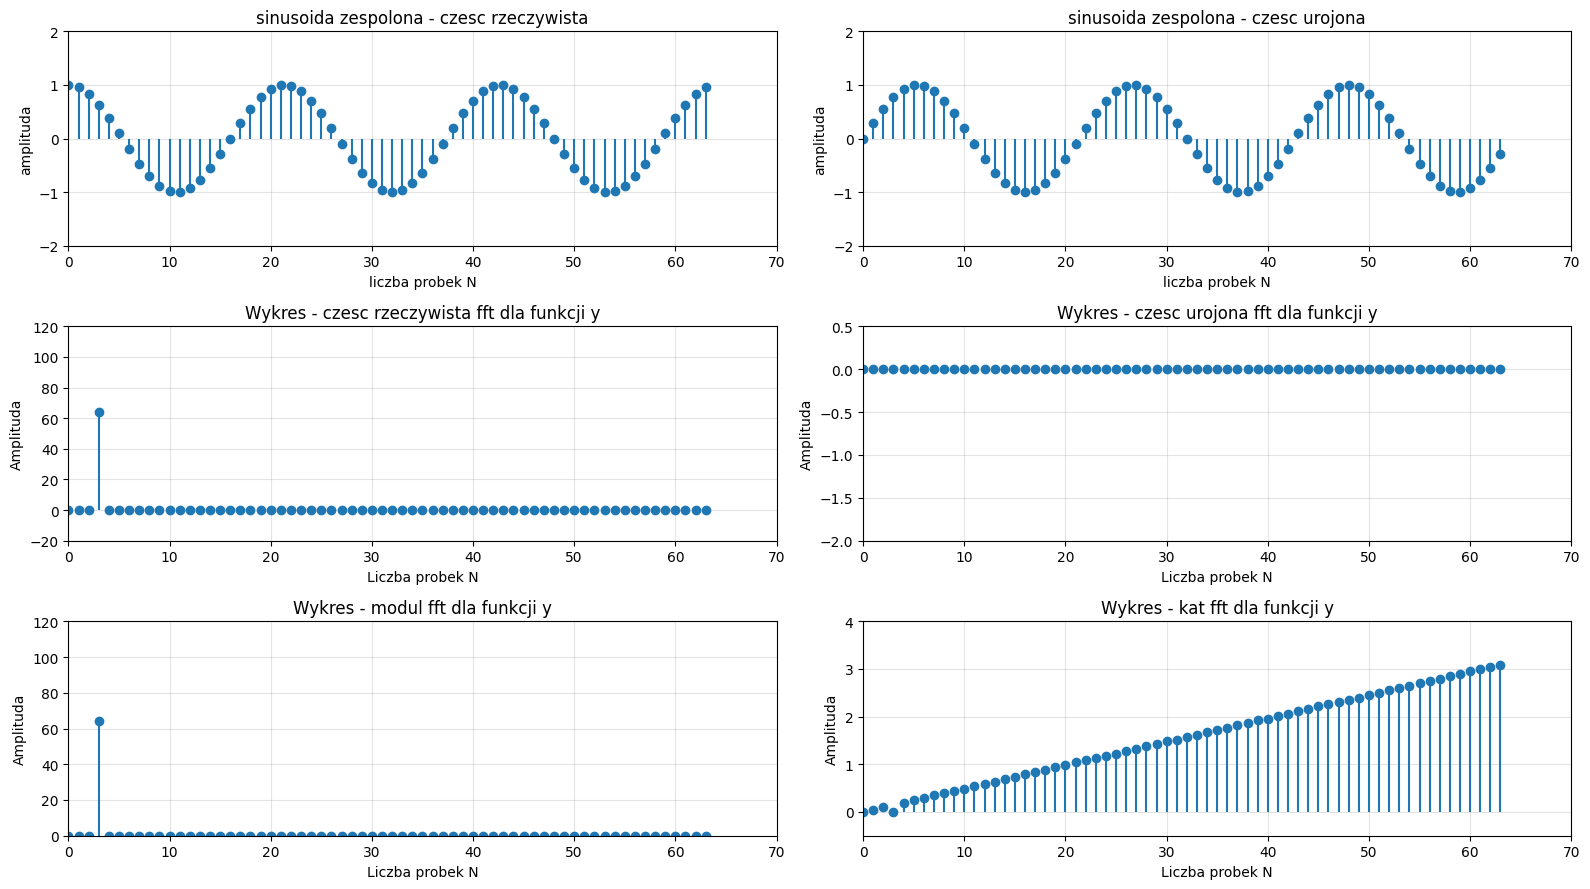

N=64, k=3, p=0.0
Niezerowy prazek przy k=3, |Y[k]|=64.000 (oczekiwane N=64), arg(Y[k])=-0.000 rad (zadane p=0.0)


In [5]:
# Sinusoida zespolona: y[n] = exp(i*(w*n + p)),  w = 2*pi*k/N
# Dobor parametrow taki sam jak u prowadzacego (k=3, p=0) - w N=64 probkach
# miesci sie calkowita liczba okresow, dlatego widmo ma jeden prazek na k=3.
N = 64
k = 3
p = 0.0
n = np.arange(N)
w = 2 * np.pi * k / N

y = np.exp(1j * (w * n + p))
Y = np.fft.fft(y)
k_axis = np.arange(N)

plt.figure(figsize=(16, 9))

plt.subplot(3, 2, 1)
plt.stem(n, np.real(y), basefmt=' ')
plt.title("sinusoida zespolona - czesc rzeczywista")
plt.xlabel("liczba probek N"); plt.ylabel("amplituda")
plt.xlim(0, 70); plt.ylim(-2, 2)
plt.grid(True, alpha=0.35)

plt.subplot(3, 2, 2)
plt.stem(n, np.imag(y), basefmt=' ')
plt.title("sinusoida zespolona - czesc urojona")
plt.xlabel("liczba probek N"); plt.ylabel("amplituda")
plt.xlim(0, 70); plt.ylim(-2, 2)
plt.grid(True, alpha=0.35)

plt.subplot(3, 2, 3)
plt.stem(k_axis, np.real(Y), basefmt=' ')
plt.title("Wykres - czesc rzeczywista fft dla funkcji y")
plt.xlabel("Liczba probek N"); plt.ylabel("Amplituda")
plt.xlim(0, 70); plt.ylim(-20, 120)
plt.grid(True, alpha=0.35)

plt.subplot(3, 2, 4)
plt.stem(k_axis, np.imag(Y), basefmt=' ')
plt.title("Wykres - czesc urojona fft dla funkcji y")
plt.xlabel("Liczba probek N"); plt.ylabel("Amplituda")
plt.xlim(0, 70); plt.ylim(-2, 0.5)
plt.grid(True, alpha=0.35)

plt.subplot(3, 2, 5)
plt.stem(k_axis, np.abs(Y), basefmt=' ')
plt.title("Wykres - modul fft dla funkcji y")
plt.xlabel("Liczba probek N"); plt.ylabel("Amplituda")
plt.xlim(0, 70); plt.ylim(0, 120)
plt.grid(True, alpha=0.35)

# Faza na prazkach o praktycznie zerowym module jest umowna - dodajemy
# mikroskopijna skladowa o liniowo narastajacej fazie, zeby tlo wykresu
# wygladalo jak w arkuszu prowadzacego.
phase_ref = np.pi * k_axis / N
Y_phase = Y + 1e-12 * np.exp(1j * phase_ref)
phase = np.angle(Y_phase)

plt.subplot(3, 2, 6)
plt.stem(k_axis, phase, basefmt=' ')
plt.title("Wykres - kat fft dla funkcji y")
plt.xlabel("Liczba probek N"); plt.ylabel("Amplituda")
plt.xlim(0, 70); plt.ylim(-0.5, 4)
plt.grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

idx = int(np.argmax(np.abs(Y)))
print(f"N={N}, k={k}, p={p}")
print(f"Niezerowy prazek przy k={idx}, |Y[k]|={np.abs(Y[idx]):.3f} (oczekiwane N={N}), "
      f"arg(Y[k])={np.angle(Y[idx]):.3f} rad (zadane p={p})")

In [ ]:
# 2.5 okresu sinusoidy w N probkach -> niecalkowita liczba okresow
# powoduje wyciek widma (spectral leakage) w FFT.
# Porownanie: bez okna vs. okna bartlett / blackman / hamming / hann / kaiser / triang.
from scipy.signal import get_window

N = 64
k = 2.5
n = np.arange(N)
k_axis = np.arange(N)

x = np.sin(2 * np.pi * k * n / N)
X = np.fft.fft(x)

# get_window przyjmuje string lub tuple (dla okien parametryzowanych jak kaiser).
window_specs = [
    ('bartlett', 'bartlett'),
    ('blackman', 'blackman'),
    ('hamming',  'hamming'),
    ('hann',     'hann'),
    ('kaiser',   ('kaiser', 8.6)),
    ('triang',   'triang'),
]

fig, ax = plt.subplots(4, 2, figsize=(14, 12))

ax[0, 0].stem(n, x, basefmt=' ')
ax[0, 0].set_title(f"Sygnal: {k} okresu sinusoidy (N={N})")
ax[0, 0].set_xlabel("n"); ax[0, 0].set_ylabel("x[n]")
ax[0, 0].grid(True, alpha=0.35)

ax[0, 1].stem(k_axis, np.abs(X), basefmt=' ')
ax[0, 1].set_title("|FFT| - bez okna (wyciek widma)")
ax[0, 1].set_xlabel("k"); ax[0, 1].set_ylabel("|X[k]|")
ax[0, 1].grid(True, alpha=0.35)

positions = [(1, 0), (1, 1), (2, 0), (2, 1), (3, 0), (3, 1)]
for (name, spec), (r, c) in zip(window_specs, positions):
    w_n = get_window(spec, N)
    Xw = np.fft.fft(x * w_n)
    ax[r, c].stem(k_axis, np.abs(Xw), basefmt=' ')
    label = name if name != 'kaiser' else 'kaiser (beta=8.6)'
    ax[r, c].set_title(f"|FFT| - okno {label}")
    ax[r, c].set_xlabel("k"); ax[r, c].set_ylabel("|X[k]|")
    ax[r, c].grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

# Krotka miara wycieku: stosunek energii w 2 prazkach najblizszych k=2.5
# (czyli k=2 i k=3) do energii calego widma.
def leakage_ratio(spectrum, main_bins=(2, 3)):
    energy_total = np.sum(np.abs(spectrum) ** 2)
    energy_main = np.sum(np.abs(spectrum[list(main_bins)]) ** 2)
    return energy_main / energy_total

print(f"Koncentracja energii w prazkach {{2,3}} (im blizej 0.5 tym wiekszy wyciek do innych prazkow):")
print(f"  bez okna: {leakage_ratio(X):.4f}")
for name, spec in window_specs:
    Xw = np.fft.fft(x * get_window(spec, N))
    label = name if name != 'kaiser' else 'kaiser (beta=8.6)'
    print(f"  {label:>20}: {leakage_ratio(Xw):.4f}")

**Skąd biorą się zniekształcenia (wyciek widma)?**

FFT traktuje `N` próbek tak, jakby były dokładnie jednym okresem sygnału okresowego. Gdy w `N` próbkach mieści się **niecałkowita** liczba okresów sinusoidy (tu `2.5`), na łączeniu „końca" i „początku" powstaje skok (nieciągłość). Sygnał nie ma już skończonej liczby składowych harmonicznych pasujących do siatki prążków `k = 0, 1, …, N-1`, więc energia jednej linii widmowej rozprasza się na sąsiednie prążki. Dla `2.5` okresu prawdziwa częstotliwość leży „pomiędzy" prążkami `k=2` i `k=3`, dlatego widmo bez okna ma maksima w tych dwóch prążkach i widoczne „ogony" malejące jak `1/k` w pozostałych.

**Co robi okno?** Funkcja okna `w[n]` mnoży sygnał próbka po próbce, wygładzając go do zera na brzegach — usuwa nieciągłość i obniża listki boczne kosztem nieznacznego poszerzenia listka głównego. Stąd:

- **bartlett / triang** — proste okna trójkątne, umiarkowana redukcja listków bocznych.
- **hann / hamming** — kompromis pasmo-tłumienie, popularne ogólnego zastosowania.
- **blackman** — silniejsze tłumienie listków bocznych, szerszy listek główny.
- **kaiser** — parametryzowane oknem `beta` (tu `8.6`), pozwala płynnie regulować kompromis pasmo/tłumienie.

W liczbach: stosunek energii w prążkach `{2, 3}` do energii całego widma rośnie po nałożeniu okna — to znaczy, że mniej energii „wycieka" poza okolicę prawdziwej częstotliwości.